# Transfer Learning using Tensorflow

## Part 1 - Data Preprocessing

### Importing the libraries

In [1]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix

### Loading Intel image dataset from kaggle

In [2]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print(path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
/kaggle/input/intel-image-classification


In [3]:
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


## Defining Class Names

In [5]:
class_names = train_dataset.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Visualising the images

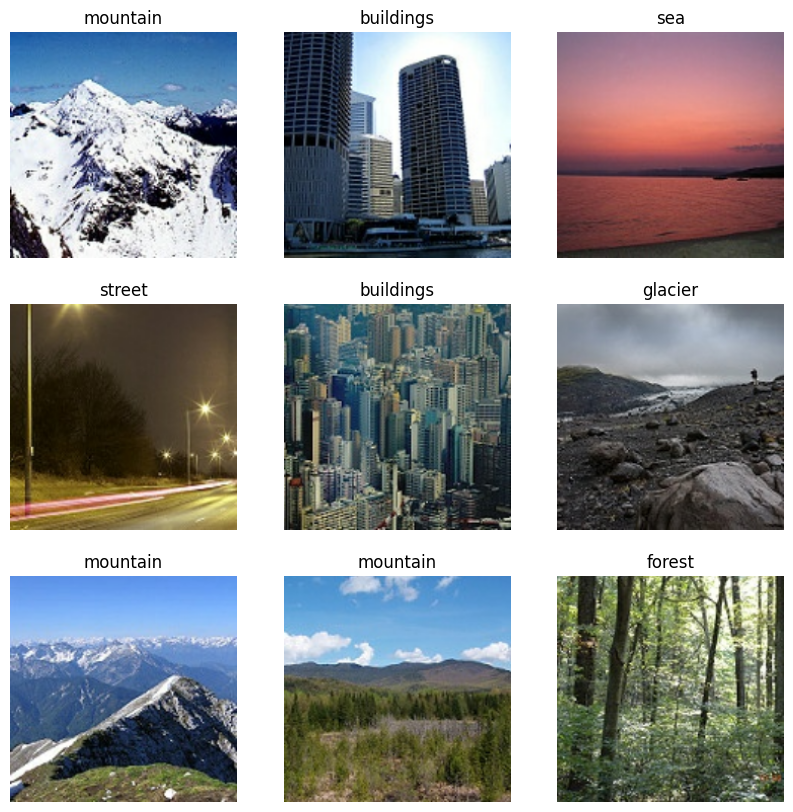

In [6]:
plt.figure(figsize = (10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Normalizing the images

In [7]:
normalization = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y:(normalization(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y:(normalization(x), y)
)

## Part 2 - Feature Extraction using TensorFlow

### Loading the pretrained MobileNetV2

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    include_top = False,
    weights = "imagenet",
    input_shape = (224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Freezing the convolutional base

In [9]:
base_model.trainable = False

### Building the transfer learning model

In [10]:
model = tf.keras.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation = "relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation = "softmax"
    )

])

### Compiling the model

In [11]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

### Training the model (Feature Extraction)

In [12]:
history = model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = 5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 101s 171ms/step - accuracy: 0.8760 - loss: 0.3401 - val_accuracy: 0.9093 - val_loss: 0.2387
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9077 - loss: 0.2481 - val_accuracy: 0.9107 - val_loss: 0.2272
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9187 - loss: 0.2183 - val_accuracy: 0.9157 - val_loss: 0.2270
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9274 - loss: 0.1950 - val_accuracy: 0.9183 - val_loss: 0.2184
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9351 - loss: 0.1747 - val_accuracy: 0.9133 - val_loss: 0.2328


### Evaluating the model

In [13]:
loss, accuracy = model.evaluate(
    test_dataset
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9133 - loss: 0.2328


In [14]:
print("Accuracy :", accuracy)

Accuracy : 0.9133333563804626


## Part 3 - Fine-Tuning

### Unfreezing the last layers

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

### Recompiling the model

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-5),
    loss="sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

### Fine-Tuning the model

In [17]:
history_finetune = model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = 5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 56s 88ms/step - accuracy: 0.8532 - loss: 0.4181 - val_accuracy: 0.9137 - val_loss: 0.2510
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9094 - loss: 0.2485 - val_accuracy: 0.9223 - val_loss: 0.2276
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9225 - loss: 0.2097 - val_accuracy: 0.9217 - val_loss: 0.2276
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9327 - loss: 0.1801 - val_accuracy: 0.9210 - val_loss: 0.2247
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9394 - loss: 0.1600 - val_accuracy: 0.9237 - val_loss: 0.2239


### Evaluating the fine-tuned model

In [18]:
loss, accuracy = model.evaluate(
    test_dataset
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9237 - loss: 0.2239


In [19]:
print("Accuracy :",accuracy)

Accuracy : 0.9236666560173035


### Predicting the test set

In [20]:
predictions = model.predict(test_dataset)

predictions = np.argmax(
    predictions,
    axis = 1
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step


### Making the confusion matrix

In [21]:
actual = []

for images,labels in test_dataset:
    actual.extend(labels.numpy())

actual = np.array(actual)

In [22]:
cm = confusion_matrix(actual, predictions)
print(cm)

[[414   1   0   0   2  20]
 [  0 472   1   1   0   0]
 [  0   4 457  79  11   2]
 [  2   3  38 473   8   1]
 [  2   1   4  10 493   0]
 [ 37   0   0   1   1 462]]


## Part 4 - Predicting New Images

### Loading a new image

In [23]:
from tensorflow.keras.preprocessing import image

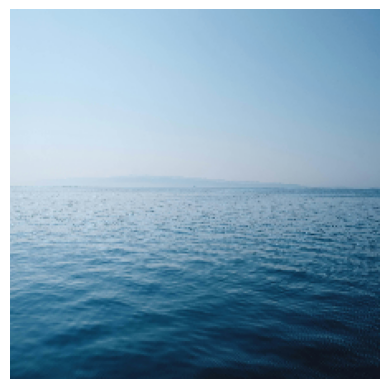

In [24]:
image_path = "image.jpg"

img = image.load_img(
    image_path,
    target_size = (224, 224)
)

plt.imshow(img)
plt.axis("off")
plt.show()

### Preprocessing the image

In [25]:
img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis = 0
)

img_array = img_array / 255.0

### Predicting the image class

In [26]:
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
print("Predicted Class :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Predicted Class : sea


## Part 6 - Saving the Model

### Saving the TensorFlow model

In [27]:
model.save("transfer_learning_model.keras")

### Loading the saved model

In [28]:
loaded_model = tf.keras.models.load_model(
    "transfer_learning_model.keras"
)